In [140]:
import os, io
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

# import torch

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
# from torch.autograd import Variable
# from classes.classifier import VocalClassifier
# from classes.recording import Recording
# from classes.list_of_vocals import ListOfVocals
# from classes.vocal import Vocal

In [5]:
recording = np.load('/Users/gustavo/Documents/git/vocalpy/audios/audio_example_outputs/recording.vocalpy', allow_pickle=True)

In [11]:
path_to_spectrogram = '../audios/example_outputs/spectrogram'
ClassClassifier = VocalClassifier(type='class', path_to_spectrograms=recording.spectrogram_dir)
predictions = ClassClassifier.classify_list_of_vocals(recording.list_of_vocals)

In [14]:
spectrogram = np.array(Image.open("/Users/gustavo/Documents/git/vocalpy/audios/example_outputs/spectrogram/4_5.png"))

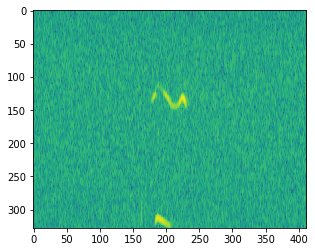

In [15]:
plt.imshow(spectrogram)

In [107]:
coords = np.random.randint(75,150,(50,2))

[312 260 300 248 299 243 309 282 303 309 270 307 307 261 293 309 300 259
 286 303 246 285 280 279 276 295 294 260 295 251 271 298 251 257 270 275
 291 259 287 261 306 251 276 303 242 286 291 295 266 250]
[148  96 136  84 135  79 145 118 139 145 106 143 143  97 129 145 136  95
 122 139  82 121 116 115 112 131 130  96 131  87 107 134  87  93 106 111
 127  95 123  97 142  87 112 139  78 122 127 131 102  86]


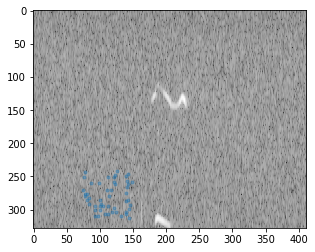

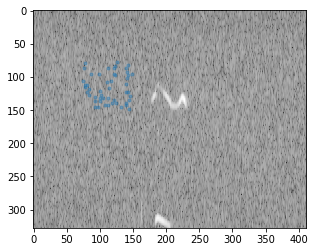

In [115]:
plt.figure()
plt.imshow(spectrogram, cmap='gray')
col_values = coords[:, 0]
row_values = coords[:, 1]
plt.scatter(col_values, row_values, marker='.', alpha=0.4)

plt.figure()
plt.imshow(spectrogram, cmap='gray')
# flip row values upside down
row_size_half = spectrogram.shape[0]//2
print(row_values)
lower_half = np.where(row_values[row_values < row_size_half])
upper_half = np.where(row_values[row_values > row_size_half])
row_values[lower_half] = row_values[lower_half] + row_size_half
row_values[upper_half] = row_values[upper_half] - row_size_half
print(row_values)
plt.scatter(col_values, row_values, marker='.', alpha=0.4)

In [121]:
buf = io.BytesIO()
plt.savefig(buf, bbox_inches='tight', format='png')
plt.close()
buf.seek(0)
img = Image.open(buf)
img = img.transpose(Image.FLIP_TOP_BOTTOM)

In [124]:
Image.

AttributeError: module 'PIL.Image' has no attribute 'plot'

In [78]:
row_values = coords[:, 1]
print(row_values)
row_values[row_values < row_size_half] = row_values[row_values > row_size_half] + row_size_half
print(row_values)

[124 120  97 143 121 141  94  97  91 113 149 127  86 101  88 140  75 141
  85  77 136  93 110  87  75 132 141  86 149 105 146  96 124  81  98  80
 143 110 107 128 102  80 104  80  97 130 138  79 102  88]
[124 120  97 143 121 141  94  97  91 113 149 127  86 101  88 140  75 141
  85  77 136  93 110  87  75 132 141  86 149 105 146  96 124  81  98  80
 143 110 107 128 102  80 104  80  97 130 138  79 102  88]


In [86]:
row_values = coords[:, 1]

In [93]:
row_values[row_values < row_size_half] = row_values[row_values < row_size_half] + row_size_half

In [92]:
row_values

array([ 82, 125, 185, 165, 144, 166, 154, 193, 178, 199, 188,  97, 172,
       138, 106, 105, 182, 191, 174, 177, 182, 162, 106, 166, 177, 111,
       129, 132, 152,  88, 104,  79, 175, 133, 136, 118, 149, 120, 148,
       125, 102, 195, 163, 172, 187, 124, 104, 138, 114, 142])

In [100]:
row_values[0:2:-1]

array([], dtype=int64)

In [150]:
import napari
import tifffile
from dask_image.imread import imread
# delayed read, loads on click @ slice
# stack = imread("/Users/gustavo/Downloads/brains/PWK/iso/iso_4031.tif")
stack = tifffile.imread("/Users/gustavo/Downloads/brains/AgrpAi14/iso_7815_cfos.tif")
with napari.gui_qt():
    napari.view_image(stack, contrast_limits=[0,2000], is_pyramid=False)